# Preprocess trajectory tensor to gene x time

This notebook loads a trajectory tensor with shape `(n_timepoints, n_trajectories, n_genes)`, averages over trajectories, transposes to `(n_genes, n_timepoints)`, and saves it as a `.npy` file in `data/raw/`.

In [3]:
from pathlib import Path
import numpy as np


def _resolve_raw_dir() -> Path:
    candidates = [Path('data/raw'), Path('../data/raw')]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find data/raw. Run this notebook from repo root or notebooks/.")


def _load_trajectory_array(path: Path) -> np.ndarray:
    suffix = path.suffix.lower()
    if suffix == '.npy':
        arr = np.load(path)
    elif suffix == '.npz':
        with np.load(path) as npz_data:
            keys = list(npz_data.keys())
            if len(keys) == 0:
                raise ValueError(f"{path.name} is empty.")
            if len(keys) > 1:
                print(f"Found multiple arrays in {path.name}: {keys}. Using '{keys[0]}'.")
            arr = npz_data[keys[0]]
    else:
        raise ValueError("Trajectory file must be .npy or .npz")

    if arr.ndim != 3:
        raise ValueError(f"Expected 3D array (timepoints, trajectories, genes), got shape {arr.shape}")
    return arr


raw_dir = _resolve_raw_dir()
trajectory_filename = 'trajectories_gene_space.npz'  # change if needed
trajectory_path = raw_dir / trajectory_filename

trajectory = _load_trajectory_array(trajectory_path)
print('Input shape (timepoints, trajectories, genes):', trajectory.shape)

mean_time_gene = trajectory.mean(axis=1)           # (n_timepoints, n_genes)
genes_by_time = mean_time_gene.T                   # (n_genes, n_timepoints)
print('Output shape (genes, timepoints):', genes_by_time.shape)

output_name = f"{trajectory_path.stem}_avg_traj_genes_by_time.npy"
output_path = raw_dir / output_name
np.save(output_path, genes_by_time)

print(f"Saved: {output_path}")

Found multiple arrays in trajectories_gene_space.npz: ['top', 'bottom', 'all']. Using 'top'.
Input shape (timepoints, trajectories, genes): (100, 50, 100)
Output shape (genes, timepoints): (100, 100)
Saved: /nfs/roberts/project/pi_sk2433/sv496/RiTINI/data/raw/trajectories_gene_space_avg_traj_genes_by_time.npy


(100, 100)

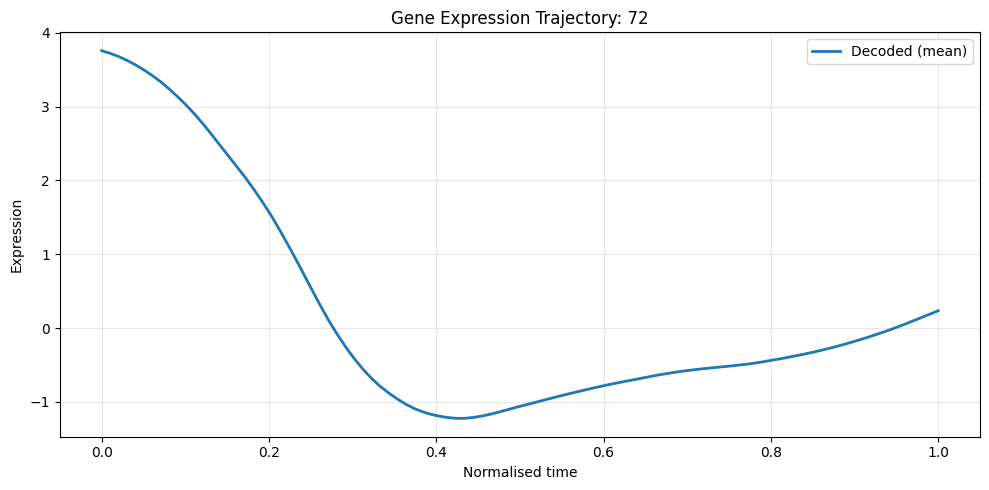

In [4]:
interest_gene = 72

# gene_mask = adata.var_names.isin([interest_gene])
# gene_traj = trajectories_gene_space[:, :, gene_mask]  # (n_bins, n_traj, 1)
# gene_mean = gene_traj.mean(axis=1).flatten()           # (n_bins,)
# gene_std  = gene_traj.std(axis=1).flatten()
gene_mean = genes_by_time[interest_gene,:]
x_time_gene = np.linspace(0, 1, len(gene_mean))

# orig_df = pd.DataFrame({
#     'expression': adata[:, gene_mask].X.toarray().flatten(),
#     'time':       obs_time_norm,
# })
# orig_mean = orig_df.groupby('time')['expression'].mean()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_time_gene, gene_mean, linewidth=2, label='Decoded (mean)')
ax.set_xlabel('Normalised time')
ax.set_ylabel('Expression')
ax.set_title(f'Gene Expression Trajectory: {interest_gene}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()